# **Seat Analysis**
 
Seat-level metrics for one run. Each seat is plotted separately.
 
## **Setup**
 
### **Imports**

In [1]:
import pathlib

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

from cambench.eval import (
  win_rate,
  win_rate_trajectory,
  belief_accuracy,
  belief_accuracy_trajectory,
  hidden_rate,
  hidden_rate_trajectory,
  role_counts,
  assassination,
)

ROOT = pathlib.Path.cwd().parent  # notebooks/ -> project root
RUNS = ROOT / "data" / "runs"
RUN_DIR = str(sorted(RUNS.iterdir())[-1])  # latest run; or set one explicitly
WINDOW = 10  # rolling window for trajectories

plt.rcParams["xtick.labelsize"] = 8  # small tick labels so long seat keys fit
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["axes.grid"] = True  # half-transparent grid lines
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.titlesize"] = 16  # suptitle larger than subplot titles
print("RUN_DIR:", RUN_DIR)

RUN_DIR: /Users/luozihyuan/Developer/camelot-bench/data/runs/260911142213-0700


### **Helpers**


In [2]:
def overall_frame(result, fields):
  """{seat: {group: {field: val}}} -> DataFrame indexed by seat, group 'overall'."""
  rows = {seat: {f: groups.get("overall", {}).get(f) for f in fields} for seat, groups in result.items()}
  return pd.DataFrame(rows).T.sort_index()


def group_frame(result, field):
  """{seat: {group: {field}}} -> DataFrame (rows=seat, cols=group) for one field."""
  rows = {seat: {g: stats.get(field) for g, stats in groups.items()} for seat, groups in result.items()}
  return pd.DataFrame(rows).T.sort_index()


def bars(df, title, ylabel, ax=None):
  own = ax is None
  ax = df.plot(kind="bar", ax=ax, figsize=(13, 6.5) if own else None, title=title, ylabel=ylabel, ylim=(0, 1.05), rot=0)
  ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
  for c in ax.containers:
    ax.bar_label(c, labels=[f"{v:.0%}" for v in c.datavalues], fontsize=8, padding=1)
  ax.legend(loc="upper right")
  if own:
    plt.tight_layout()
    plt.show()


def match_bars(result, suptitle, grouped=False):
  """Two stacked panels (exact on top, align below). `grouped` splits each panel
  by side/role; otherwise one bar per seat."""
  fig, axes = plt.subplots(2, 1, figsize=(13, 13))
  fig.suptitle(suptitle)
  for ax, metric in zip(axes, ["exact", "align"]):
    frame = group_frame(result, metric) if grouped else overall_frame(result, [metric])[metric]
    bars(frame, {"exact": "Exact", "align": "Alignment"}[metric], metric, ax=ax)
  plt.tight_layout()
  plt.show()

## **Role Assignment**
 
How many times each seat was dealt each role, as a fairness check on the random
assignment.

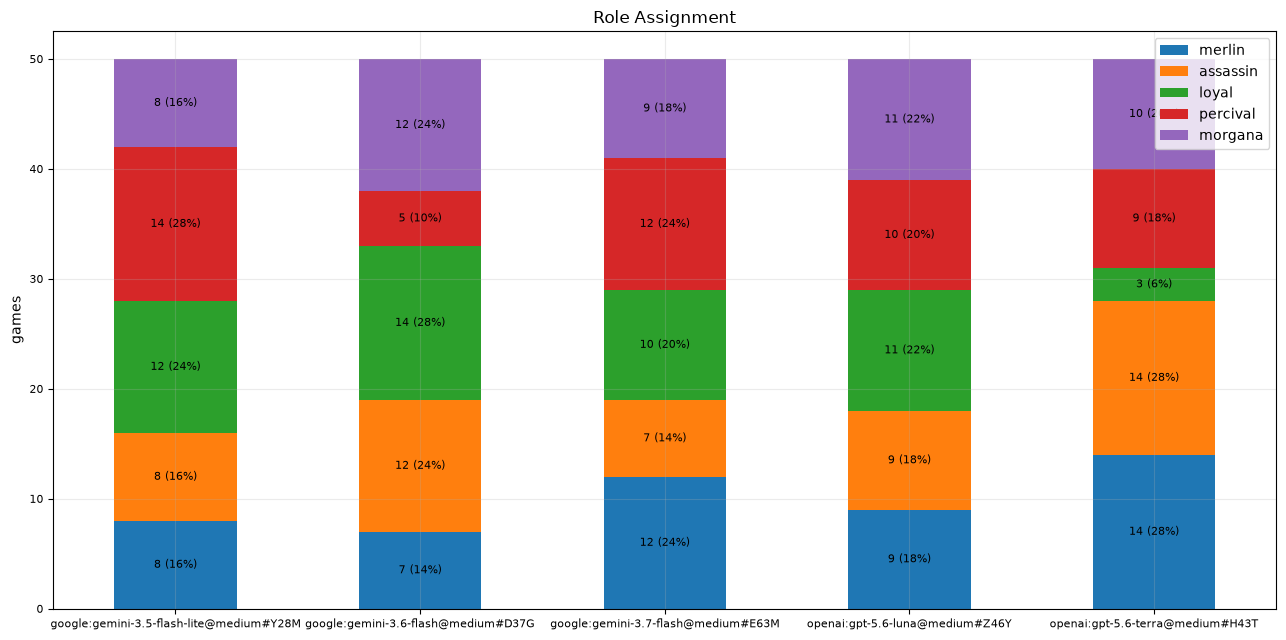

In [3]:
rc = pd.DataFrame(role_counts(RUN_DIR)).T.fillna(0).astype(int).sort_index()
totals = rc.sum(axis=1)
ax = rc.plot(kind="bar", stacked=True, figsize=(13, 6.5), title="Role Assignment", ylabel="games", rot=0)
for role, container in zip(rc.columns, ax.containers):
  labels = [f"{c} ({c / t:.0%})" if c else "" for c, t in zip(rc[role], totals)]
  ax.bar_label(container, labels=labels, label_type="center", fontsize=8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## **Win Rate**
 
Per seat, with Wilson 95% confidence intervals. Differences are meaningful only
where the intervals do not overlap.
 
### **Overall**

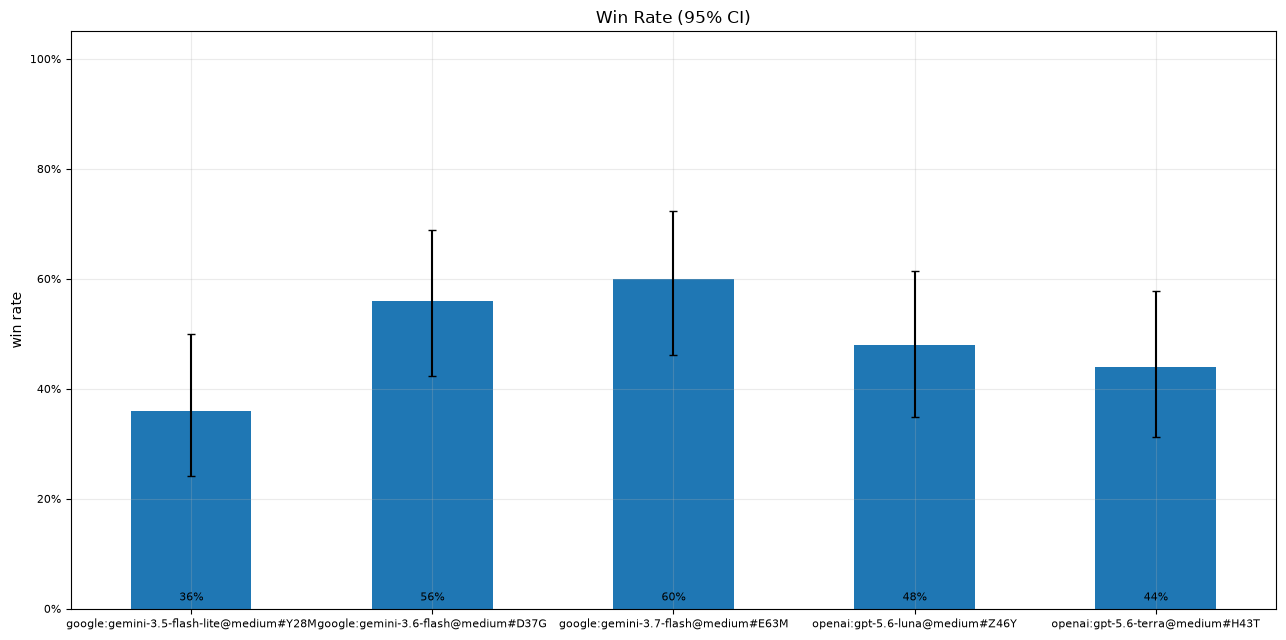

In [4]:
wr = win_rate(RUN_DIR)
df = overall_frame(wr, ["win_rate", "ci_low", "ci_high", "n"])
err = [(df["win_rate"] - df["ci_low"]).values, (df["ci_high"] - df["win_rate"]).values]
ax = df["win_rate"].plot(
  kind="bar", figsize=(13, 6.5), yerr=err, capsize=3, title="Win Rate (95% CI)", ylabel="win rate", ylim=(0, 1.05), rot=0
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
for x, v in enumerate(df["win_rate"]):
  ax.text(x, 0.01, f"{v:.0%}", ha="center", va="bottom", fontsize=8, color="black")
plt.tight_layout()
plt.show()

### **By Side**

Win rate split by the side each seat played (good vs. evil).

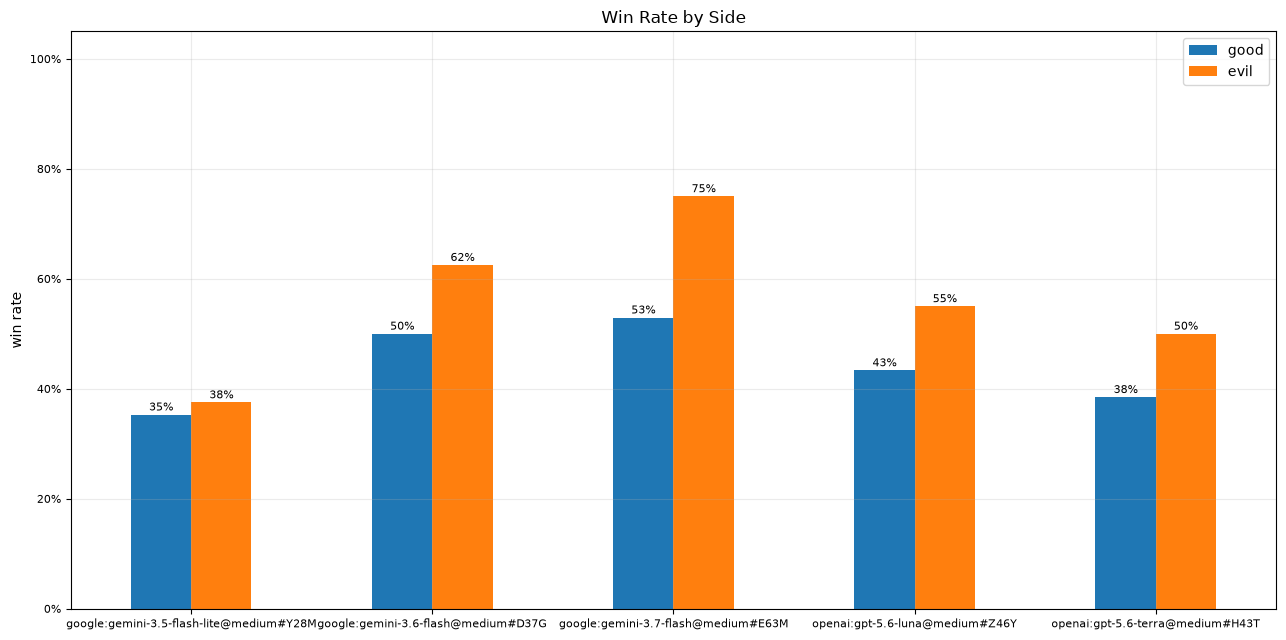

In [5]:
bars(group_frame(win_rate(RUN_DIR, by="side"), "win_rate"), "Win Rate by Side", "win rate")

### **By Role**

Win rate split by the role each seat played.

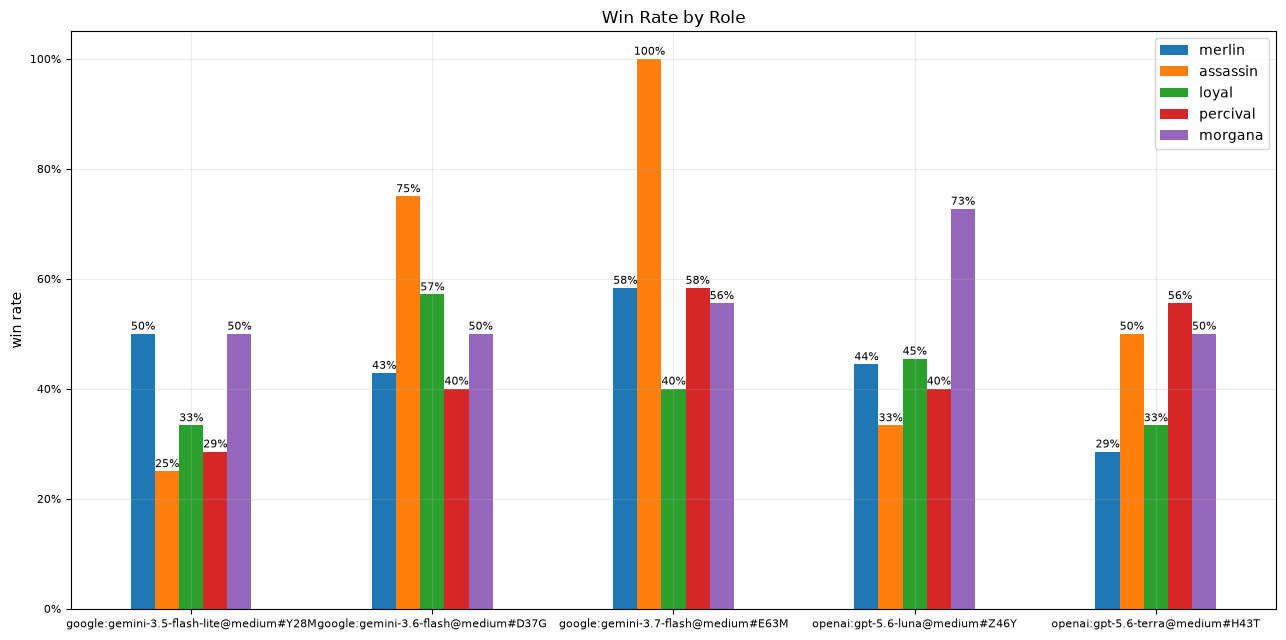

In [6]:
bars(group_frame(win_rate(RUN_DIR, by="role"), "win_rate"), "Win Rate by Role", "win rate")

## **Guess Accuracy**
 
Accuracy of each seat's role guesses (`exact`) and alignment guesses (`align`). Unguessed eligible targets are counted as incorrect.
 
### **Overall**

**Exact** counts naming a player's precise role. **Alignment** only counts getting their side (good/evil) right.

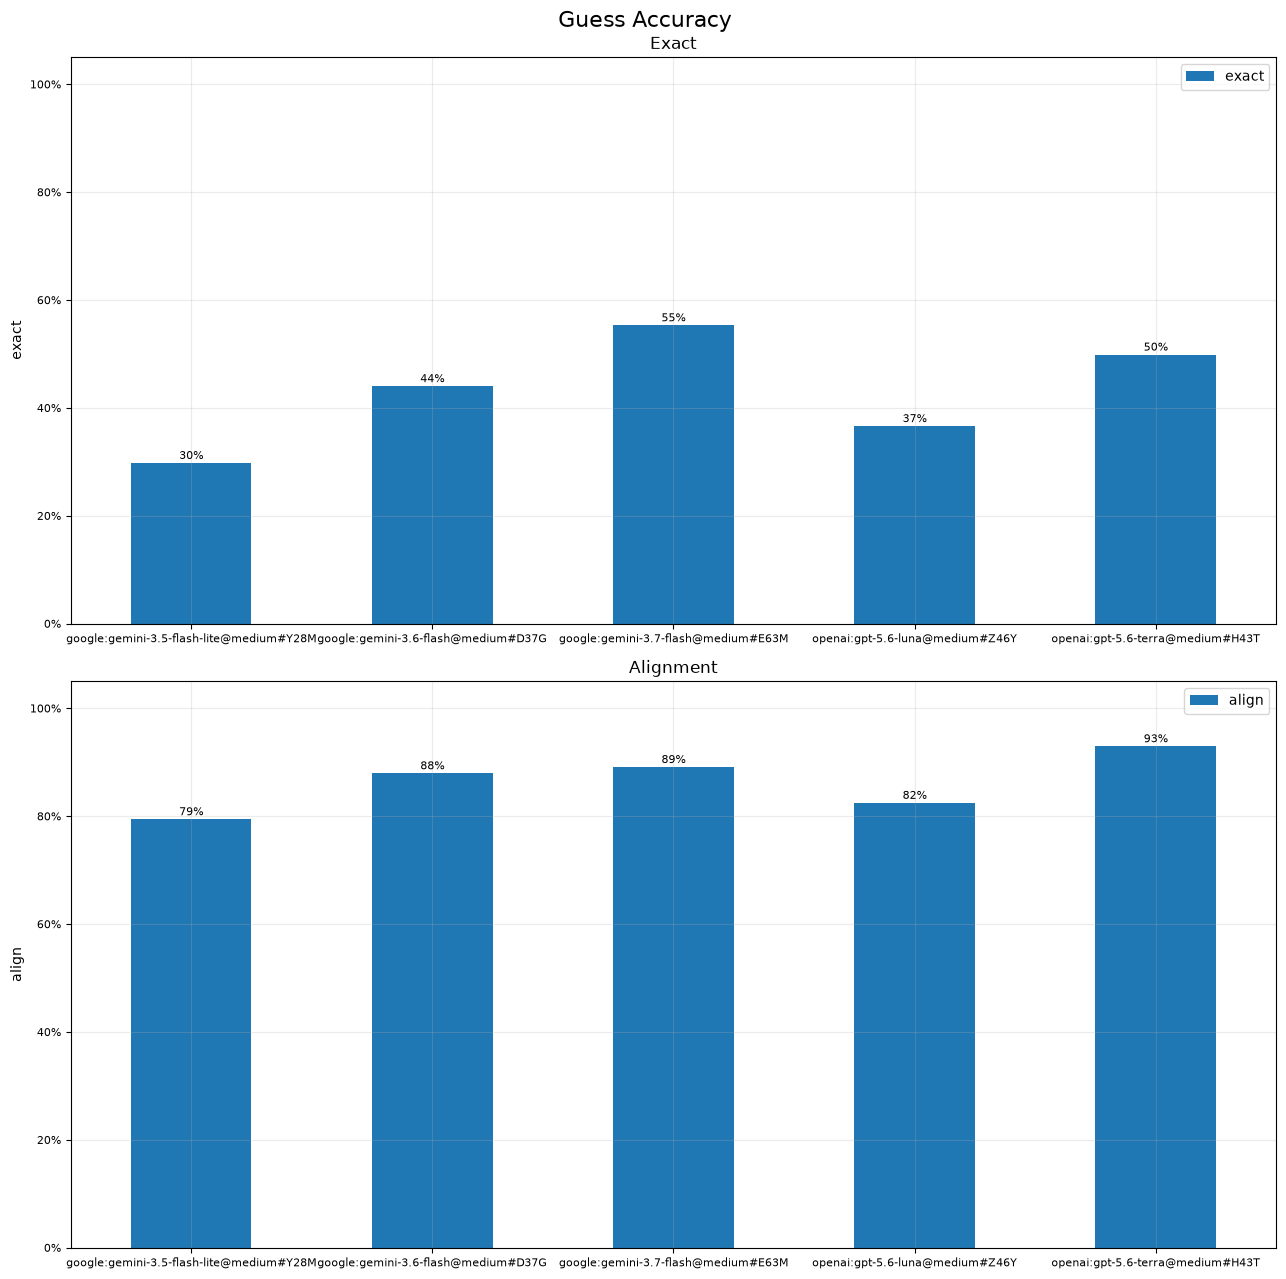

In [7]:
match_bars(belief_accuracy(RUN_DIR), "Guess Accuracy")

### **By Side**

Guess accuracy split by the guesser's own side (exact = precise role, alignment = side only).

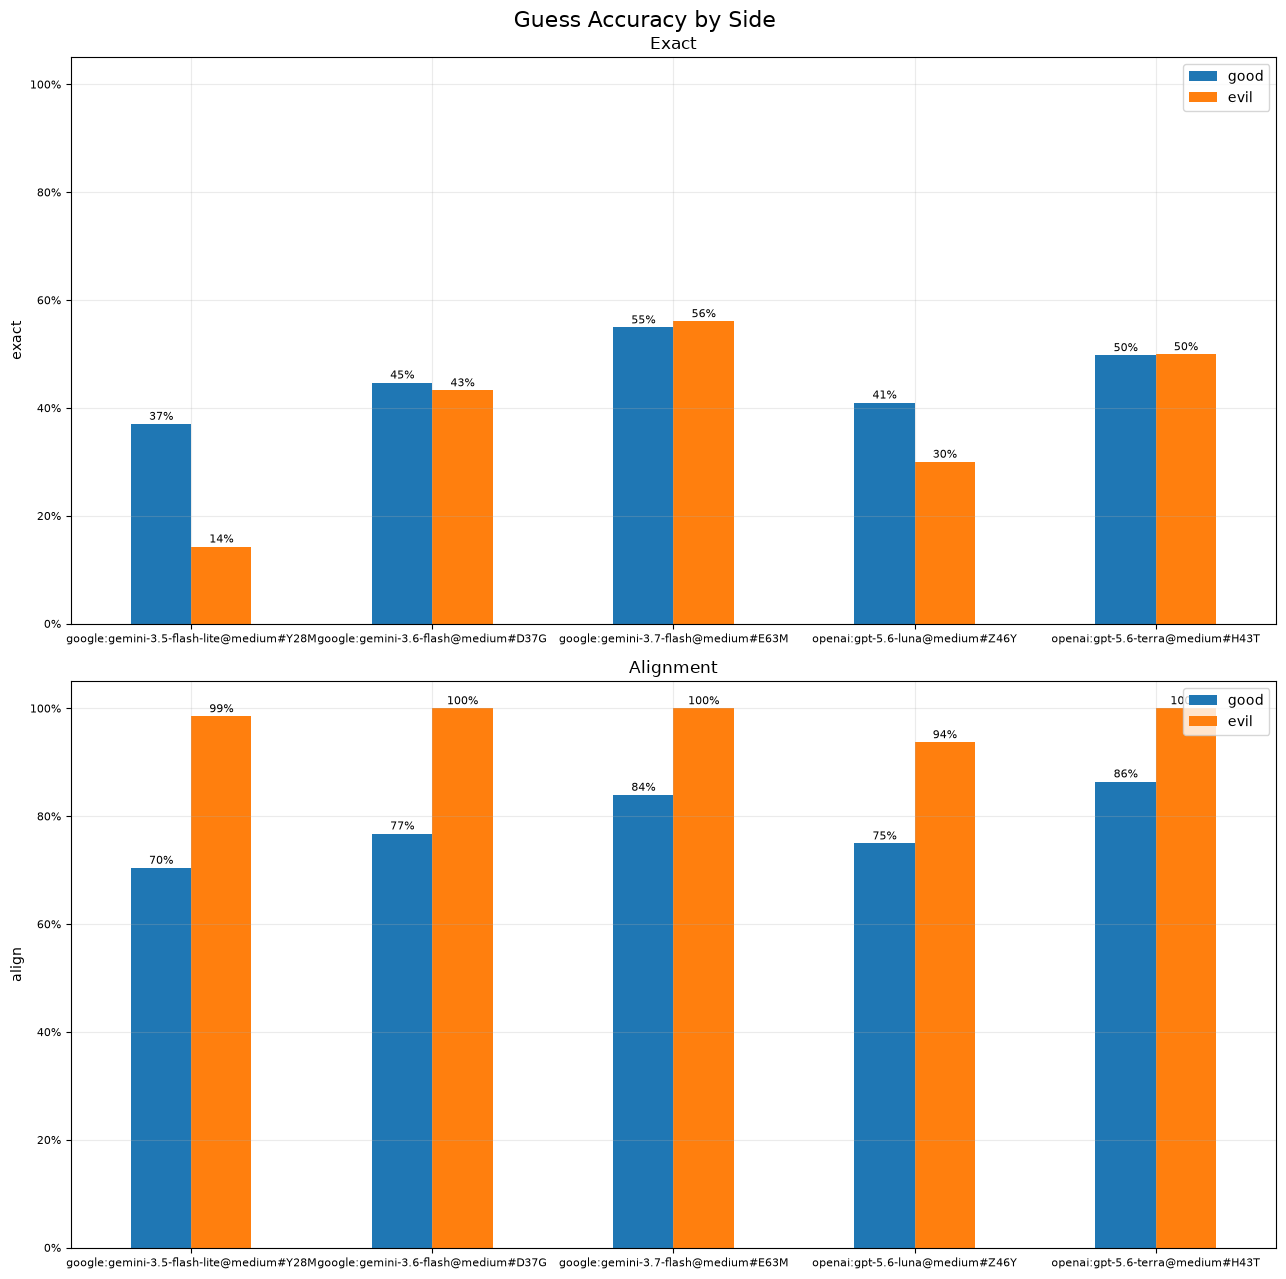

In [8]:
match_bars(belief_accuracy(RUN_DIR, by="side"), "Guess Accuracy by Side", grouped=True)

### **By Role**

Guess accuracy split by the guesser's own role (exact = precise role, alignment = side only).

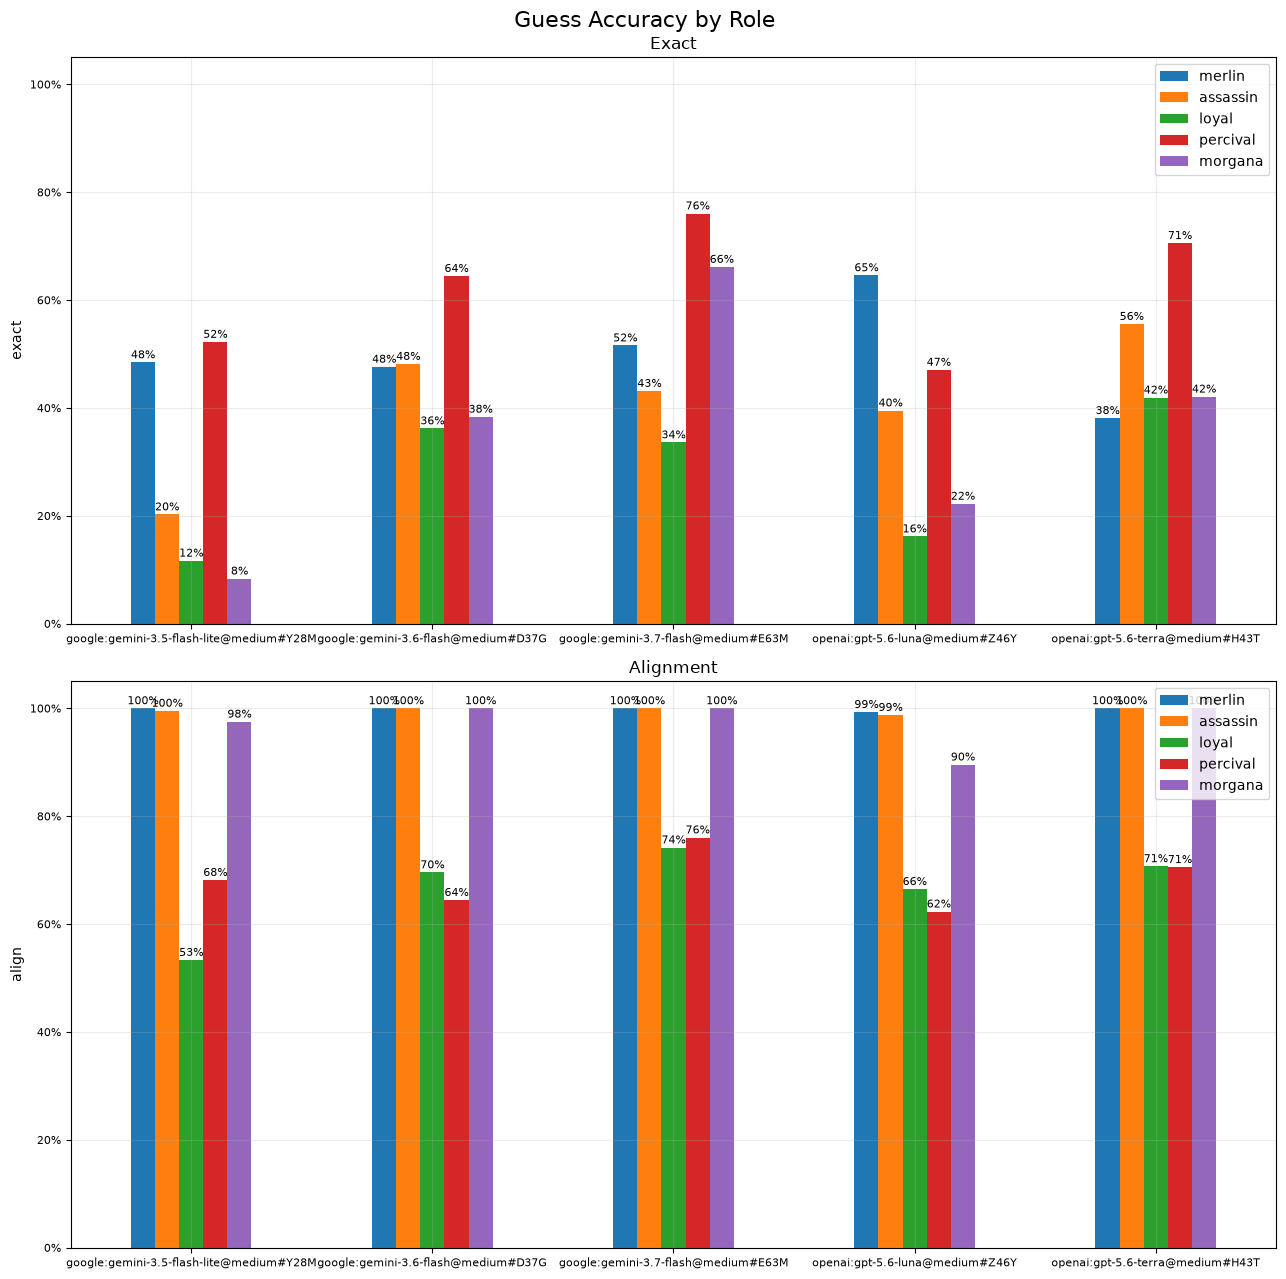

In [9]:
match_bars(belief_accuracy(RUN_DIR, by="role"), "Guess Accuracy by Role", grouped=True)

## **Hidden Rate**
 
How often other seats fail to identify each seat. Higher values indicate a seat that is harder to identify (for example, a well-concealed Merlin).
 
### **Overall**

**Exact** is how often others fail to name the seat's precise role. **Alignment** is how often they fail even to get its side.

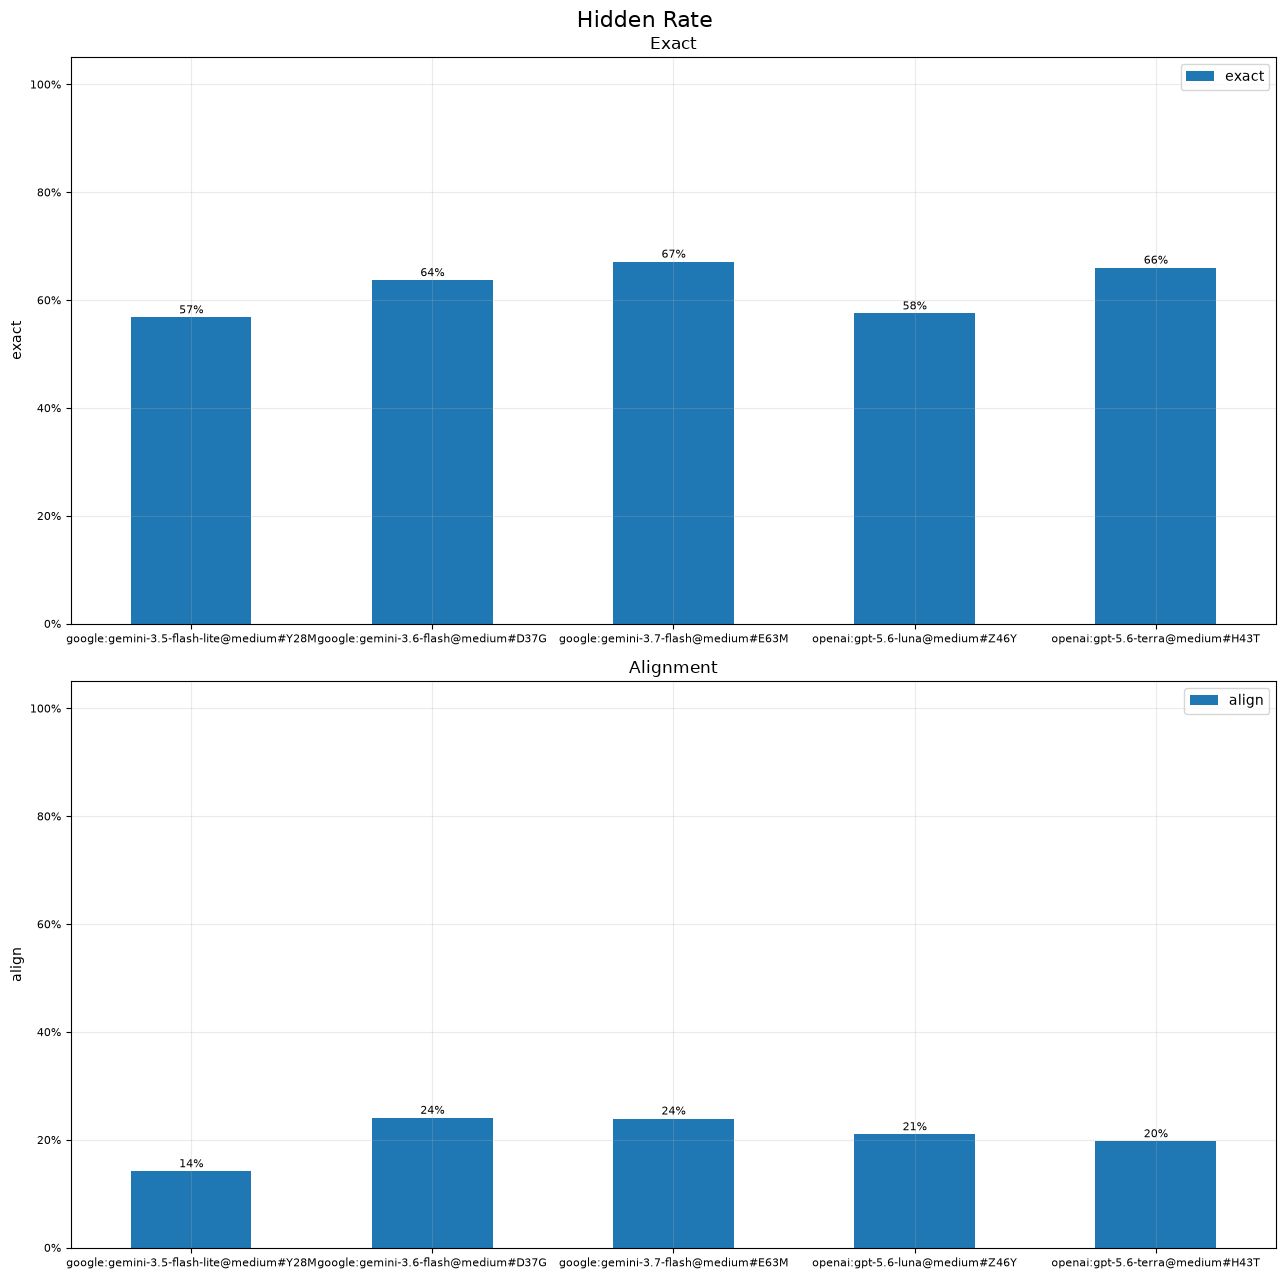

In [10]:
match_bars(hidden_rate(RUN_DIR), "Hidden Rate")

### **By Side**

Hidden rate split by the seat's own side (exact = precise role hidden, alignment = side hidden).

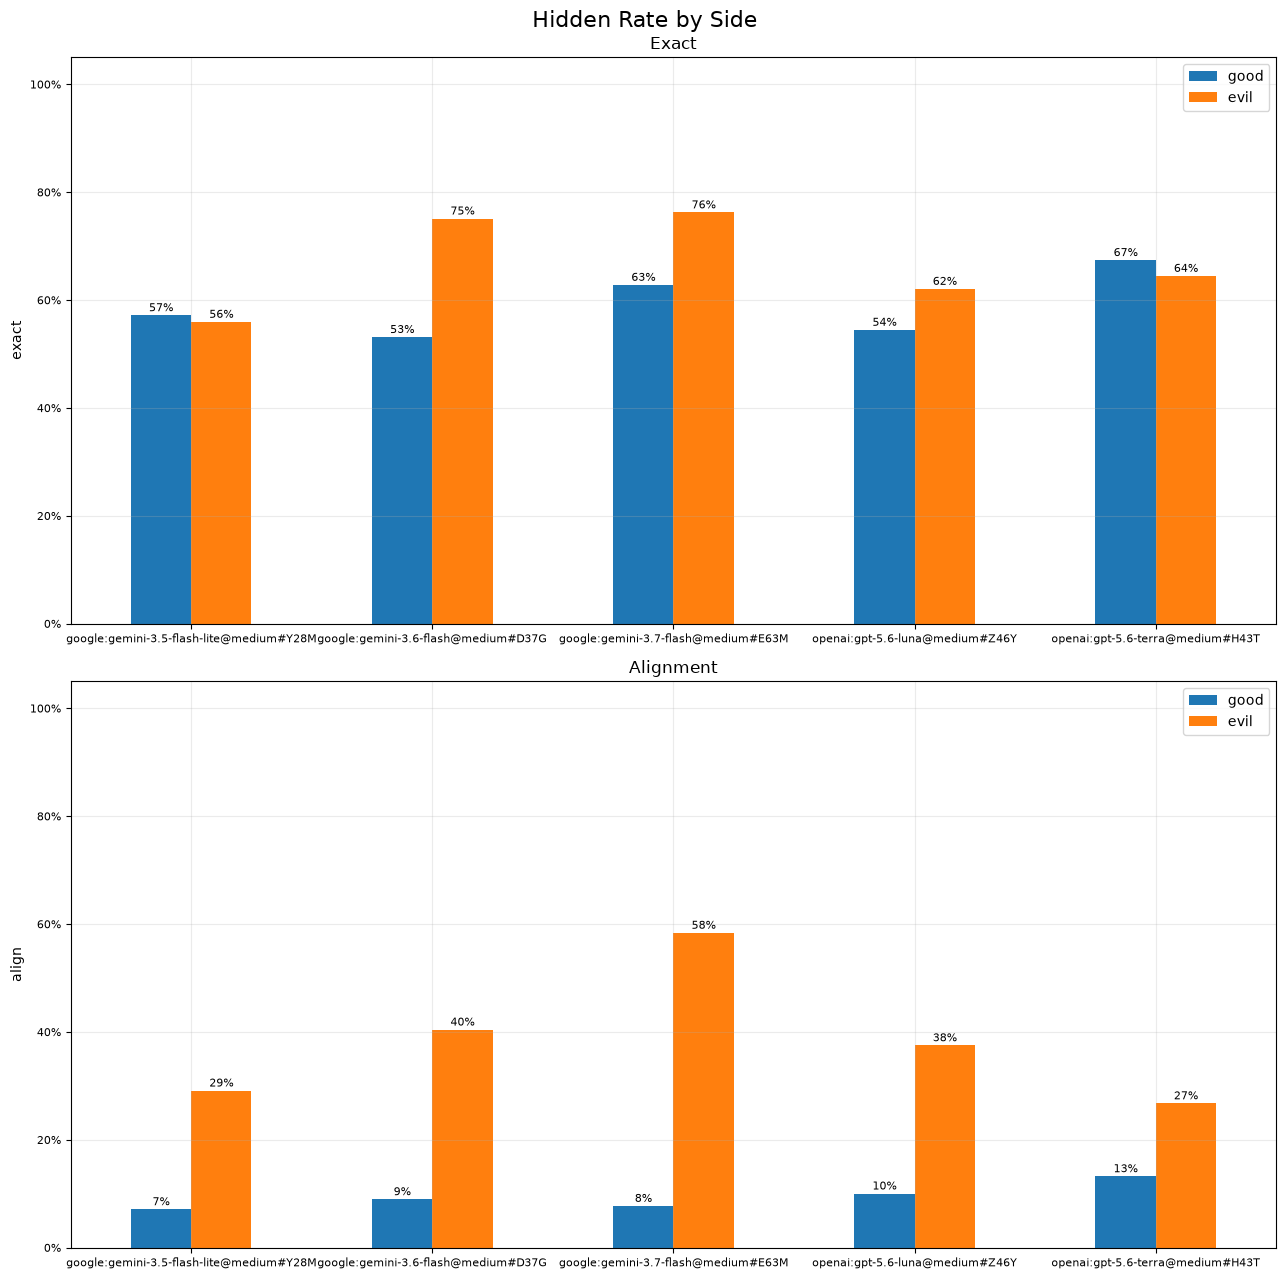

In [11]:
match_bars(hidden_rate(RUN_DIR, by="side"), "Hidden Rate by Side", grouped=True)

### **By Role**

Hidden rate split by the seat's own role (exact = precise role hidden, alignment = side hidden).

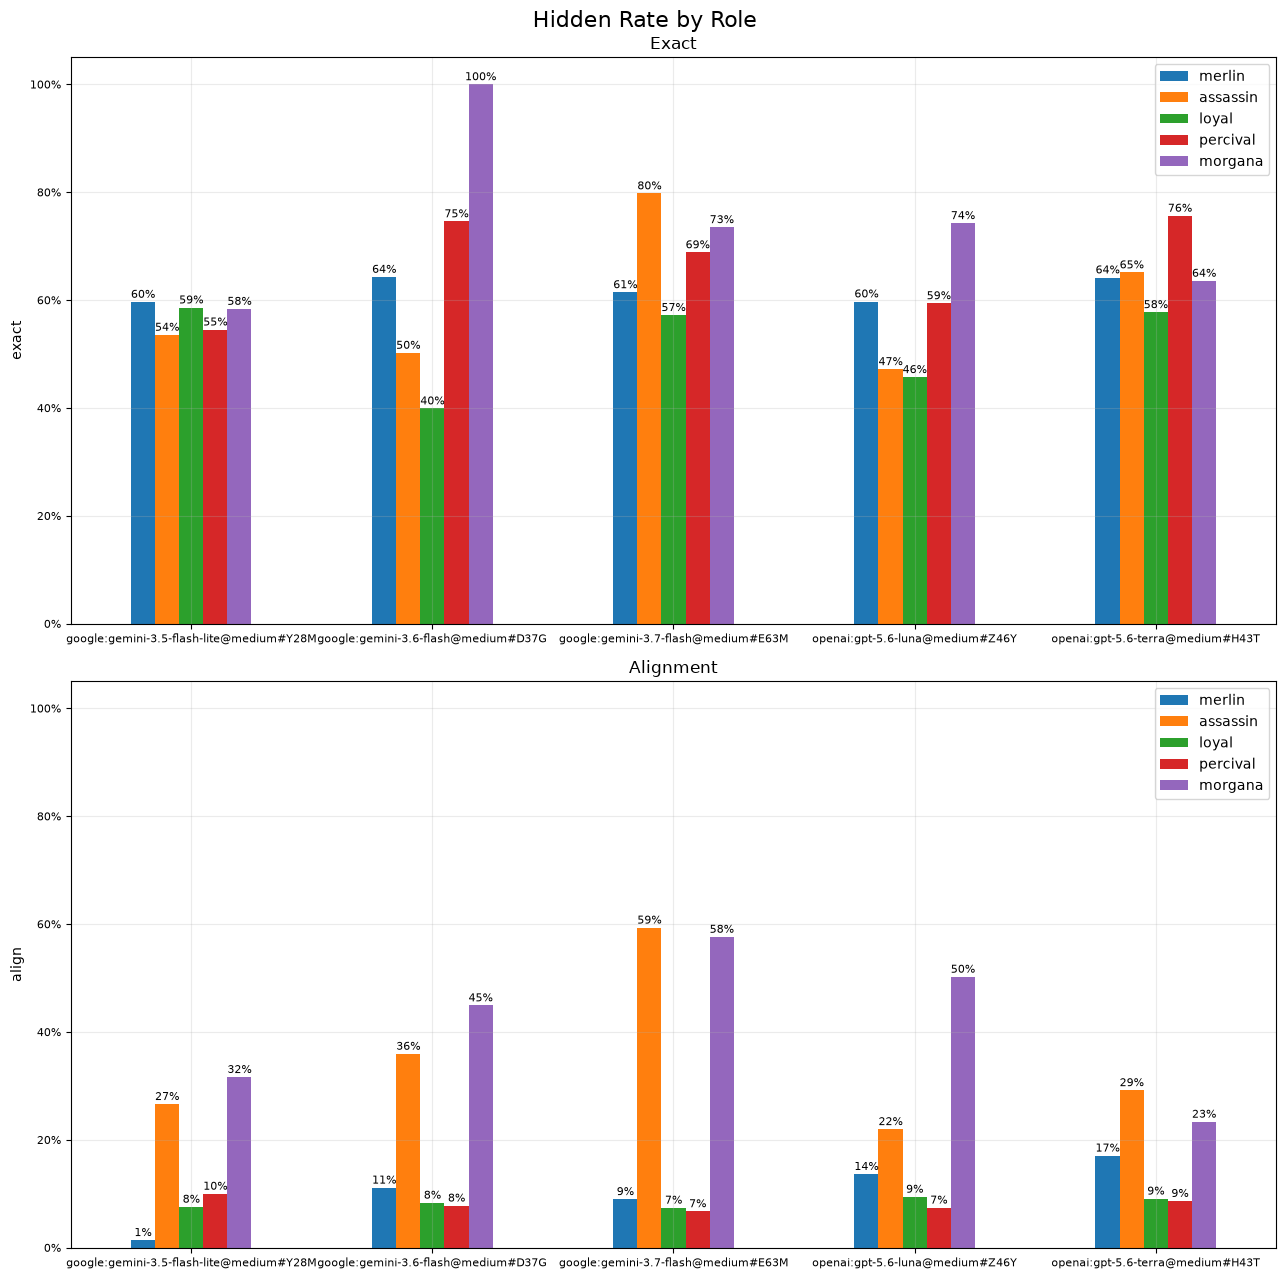

In [12]:
match_bars(hidden_rate(RUN_DIR, by="role"), "Hidden Rate by Role", grouped=True)

## **Assassination**
 
The end-game kill, per seat. Assassin accuracy is how often a seat correctly picked Merlin when it was the assassin. Merlin survival is how often a seat survived when it was Merlin. Only games that reached an assassination count, so samples are small.

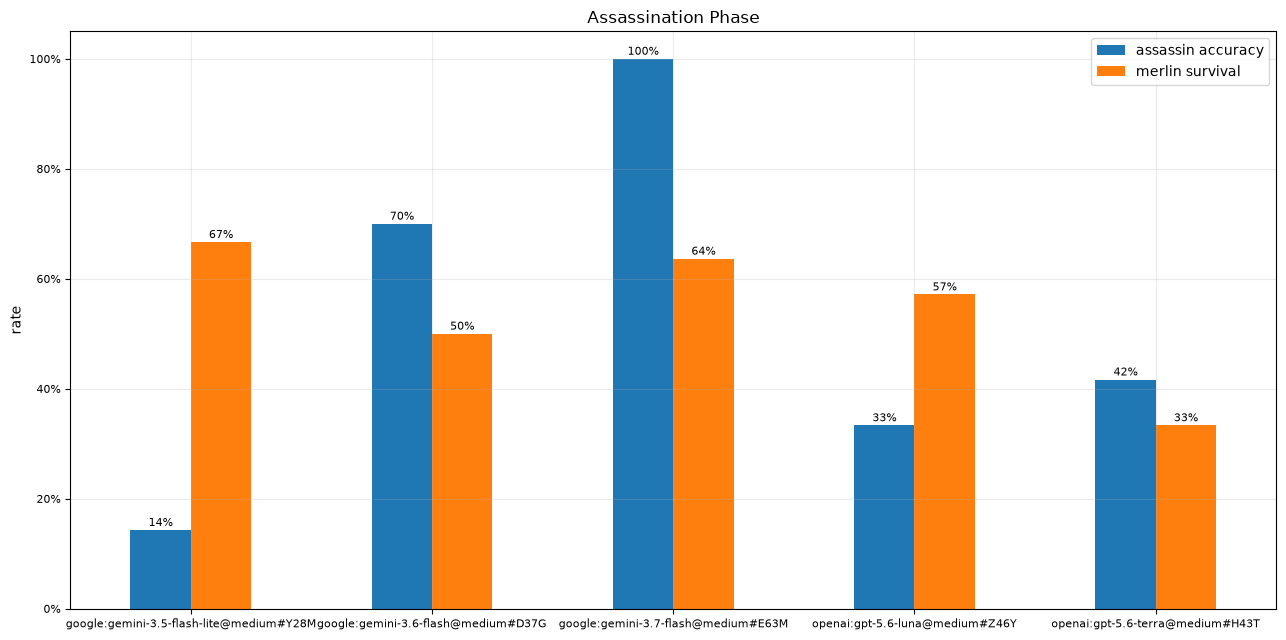

In [13]:
asn = assassination(RUN_DIR)
rates = pd.DataFrame(
  {
    "assassin accuracy": {
      k: v["as_assassin"]["hits"] / v["as_assassin"]["n"] for k, v in asn.items() if v.get("as_assassin", {}).get("n")
    },
    "merlin survival": {
      k: v["as_merlin"]["survived"] / v["as_merlin"]["n"] for k, v in asn.items() if v.get("as_merlin", {}).get("n")
    },
  }
).sort_index()
bars(rates, "Assassination Phase", "rate")

## **Trajectories**
 
Each metric as a rolling mean over games (expanding, then sliding). An upward trend indicates improvement as the seat accumulates memory.
 
### **Helper**

In [14]:
def traj_frame(traj, field=None):
  """{seat: {overall: series}} -> DataFrame (rows=game index, cols=seat)."""
  cols = {}
  for seat, groups in sorted(traj.items()):
    series = groups.get("overall")
    if not series:
      continue
    cols[seat] = series[field] if isinstance(series, dict) else series
  return pd.DataFrame(cols)


def plot_traj(traj, field, title, ylabel, ax=None):
  own = ax is None
  ax = traj_frame(traj, field).plot(
    ax=ax, figsize=(13, 6.5) if own else None, marker=".", title=title, xlabel="game", ylabel=ylabel, ylim=(0, 1)
  )
  ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
  ax.legend(loc="upper left")
  if own:
    plt.tight_layout()
    plt.show()


def match_traj(traj, suptitle):
  """Two stacked trajectory panels: exact on top, align below."""
  fig, axes = plt.subplots(2, 1, figsize=(13, 13))
  fig.suptitle(suptitle)
  for ax, metric in zip(axes, ["exact", "align"]):
    plot_traj(traj, metric, {"exact": "Exact", "align": "Alignment"}[metric], metric, ax=ax)
  plt.tight_layout()
  plt.show()

### **Win Rate**

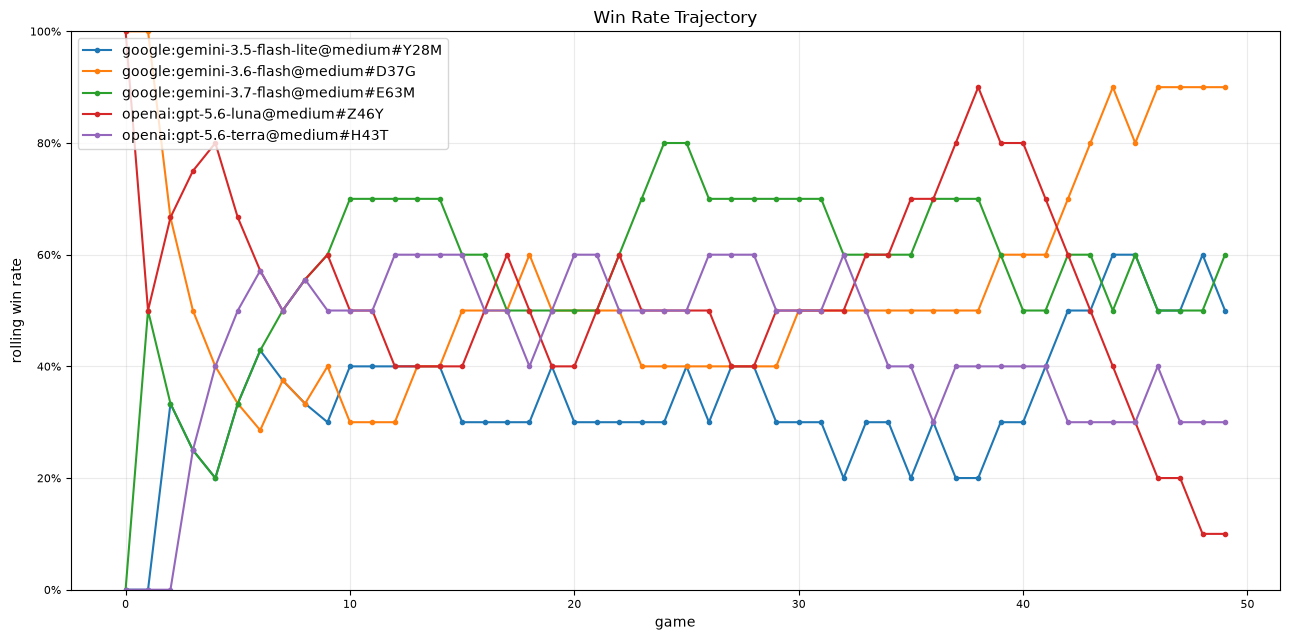

In [15]:
plot_traj(win_rate_trajectory(RUN_DIR, window=WINDOW), None, "Win Rate Trajectory", "rolling win rate")

### **Guess Accuracy**

Exact-role and alignment guess accuracy over the run, in separate panels.

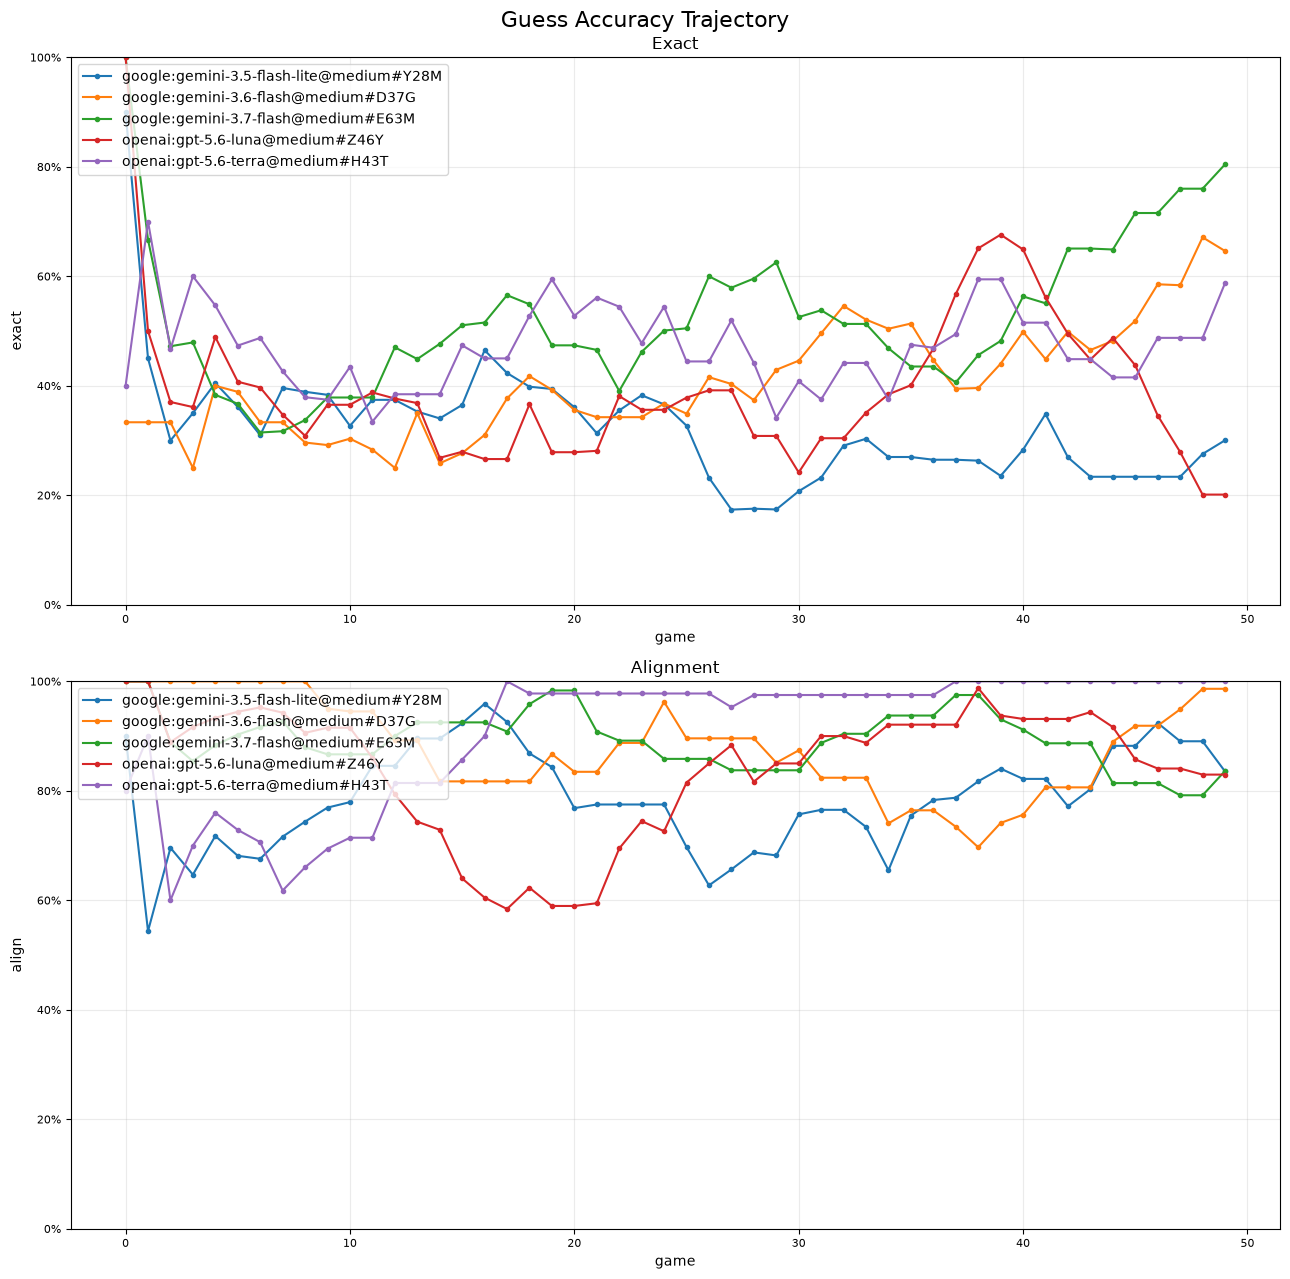

In [16]:
match_traj(belief_accuracy_trajectory(RUN_DIR, window=WINDOW), "Guess Accuracy Trajectory")

### **Hidden Rate**

Exact-role and alignment concealment over the run, in separate panels.


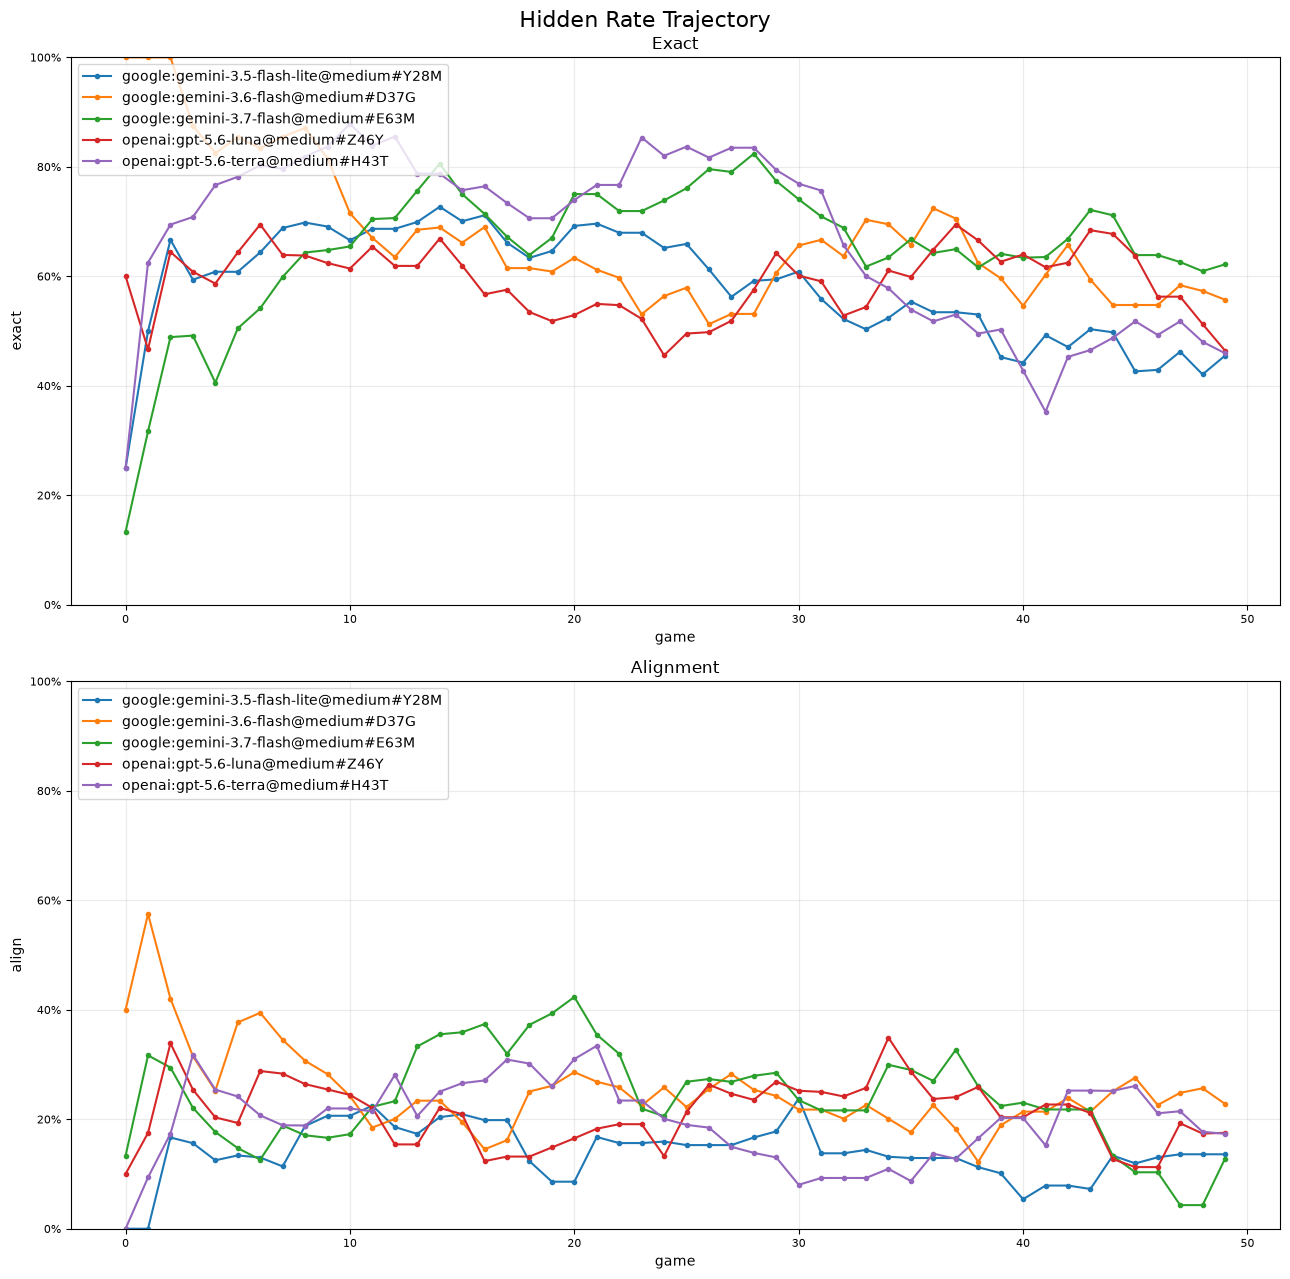

In [17]:
match_traj(hidden_rate_trajectory(RUN_DIR, window=WINDOW), "Hidden Rate Trajectory")